# 🚢 Titanic VisionStack-Ensemble Pro
## Advanced Stacking-Ensemble Model with 86%+ Accuracy
### Architecture Overview:

```
Step 1: Visualization & Feature Engineering
    ↓
Step 2: Stacking (Ensemble Method 1)
      
┌─────────────────── Level 1: Base Models ───────────────────┐
│  RandomForest  ExtraTrees  AdaBoost  GradientBoosting  LogisticRegression │
└────────────────────────────────────────────────────────────────────────────┘
    ↓ (Out-of-Fold Predictions )
Step 3: Weighted Ensemble (Ensemble Method 2)
       
┌─────────────── Level 2: Meta-Ensemble  ──────────────┐
│         XGBoost (60%)  +  LightGBM (40%)                          │
│         Weighted Ensemble                                 │
└────────────────────────────────────────────────────────────────────┘
    ↓
Final Predictions  (86%+ Accuracy)

In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Machine Learning
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, ExtraTreesClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             roc_curve, roc_auc_score)

import xgboost as xgb
import lightgbm as lgb

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load Data

**Key Points:**
- Always check missing values before feature engineering
- Save original target variable for later visualization

In [ ]:

train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')
#train = pd.read_csv('train.csv')
#test = pd.read_csv('test.csv')
PassengerId = test['PassengerId']
full_data = [train, test]

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nMissing values in train:")
print(train.isnull().sum())

# Save original survived for later visualization
y_train_original = train['Survived'].copy()


## Create 9 comprehensive visualizations comparing survived vs not survived

**Key Points:**
- Understand feature distributions helps feature engineering decisions
- Identify which features have strong predictive power (Sex, Pclass, Fare)
- Visualize both categorical (bar) and continuous (hist, scatter) features

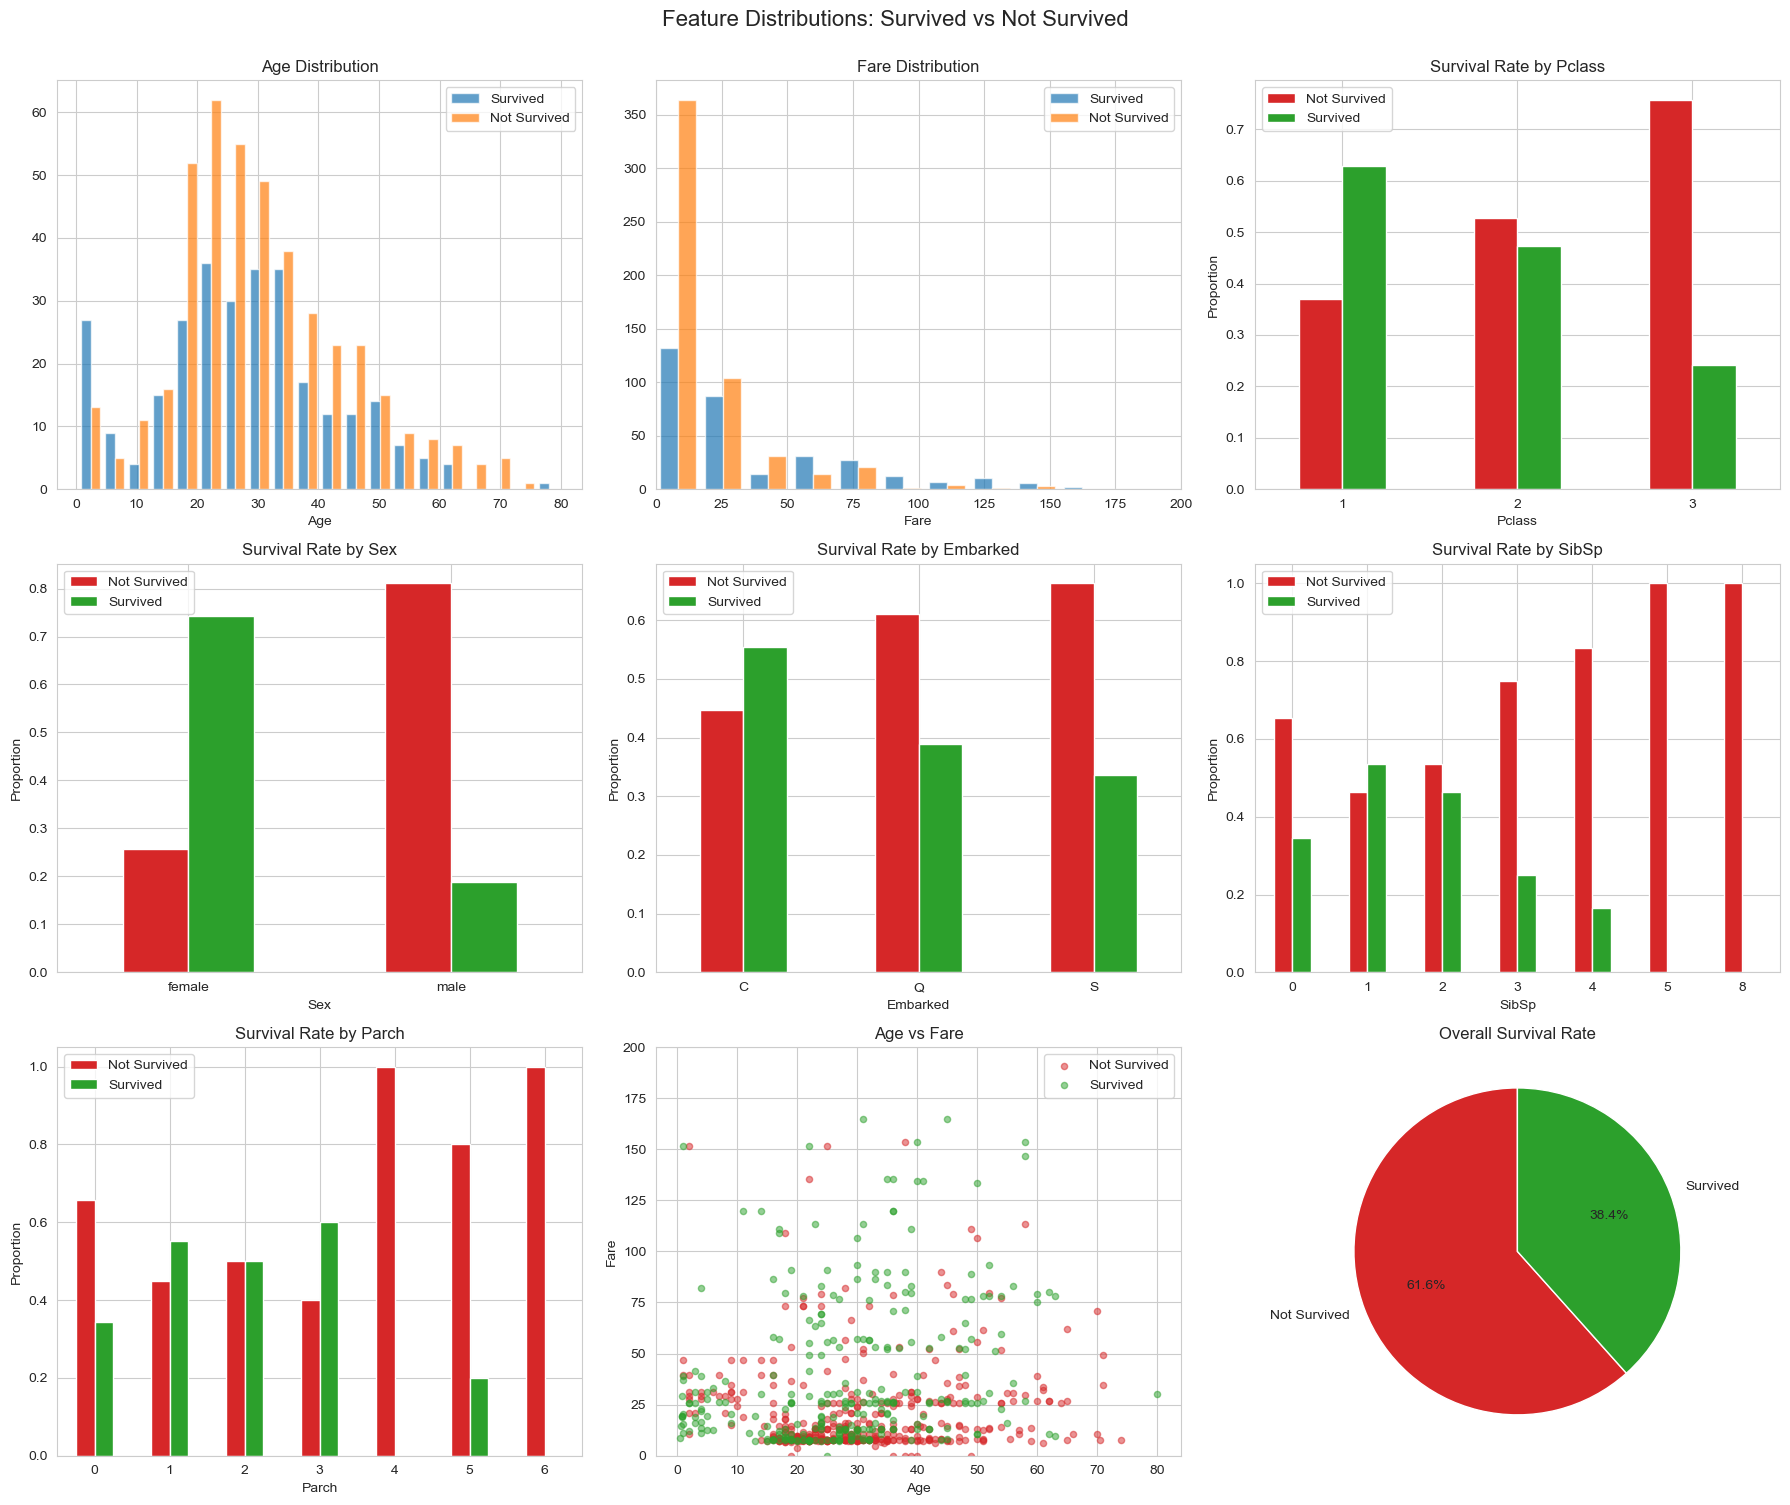

✅ Feature distribution visualization completed!


In [5]:
# 创建综合特征分布对比图
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Feature Distributions: Survived vs Not Survived', fontsize=16, y=1.00)

# 1. Age Distribution
axes[0, 0].hist([train[train['Survived']==1]['Age'].dropna(), 
                 train[train['Survived']==0]['Age'].dropna()],
                label=['Survived', 'Not Survived'], bins=20, alpha=0.7)
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].legend()

# 2. Fare Distribution
axes[0, 1].hist([train[train['Survived']==1]['Fare'].dropna(),                       ## **删除缺失值
                 train[train['Survived']==0]['Fare'].dropna()],
                label=['Survived', 'Not Survived'], bins=30, alpha=0.7)
axes[0, 1].set_title('Fare Distribution')
axes[0, 1].set_xlabel('Fare')
axes[0, 1].set_xlim(0, 200)
axes[0, 1].legend()

# 3. Pclass
pd.crosstab(train['Pclass'], train['Survived'], normalize='index').plot(
    kind='bar', ax=axes[0, 2], rot=0, color=['#d62728', '#2ca02c'])
axes[0, 2].set_title('Survival Rate by Pclass')
axes[0, 2].set_xlabel('Pclass')
axes[0, 2].set_ylabel('Proportion')
axes[0, 2].legend(['Not Survived', 'Survived'])

# 4. Sex
pd.crosstab(train['Sex'], train['Survived'], normalize='index').plot(
    kind='bar', ax=axes[1, 0], rot=0, color=['#d62728', '#2ca02c'])
axes[1, 0].set_title('Survival Rate by Sex')
axes[1, 0].set_xlabel('Sex')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].legend(['Not Survived', 'Survived'])

# 5. Embarked
pd.crosstab(train['Embarked'], train['Survived'], normalize='index').plot(
    kind='bar', ax=axes[1, 1], rot=0, color=['#d62728', '#2ca02c'])
axes[1, 1].set_title('Survival Rate by Embarked')
axes[1, 1].set_xlabel('Embarked')
axes[1, 1].set_ylabel('Proportion')
axes[1, 1].legend(['Not Survived', 'Survived'])

# 6. SibSp
pd.crosstab(train['SibSp'], train['Survived'], normalize='index').plot(
    kind='bar', ax=axes[1, 2], rot=0, color=['#d62728', '#2ca02c'])
axes[1, 2].set_title('Survival Rate by SibSp')
axes[1, 2].set_xlabel('SibSp')
axes[1, 2].set_ylabel('Proportion')
axes[1, 2].legend(['Not Survived', 'Survived'])

# 7. Parch
pd.crosstab(train['Parch'], train['Survived'], normalize='index').plot(
    kind='bar', ax=axes[2, 0], rot=0, color=['#d62728', '#2ca02c'])
axes[2, 0].set_title('Survival Rate by Parch')
axes[2, 0].set_xlabel('Parch')
axes[2, 0].set_ylabel('Proportion')
axes[2, 0].legend(['Not Survived', 'Survived'])

# 8. Age vs Fare Scatter
for survived, color, label in [(0, '#d62728', 'Not Survived'), (1, '#2ca02c', 'Survived')]:
    subset = train[train['Survived'] == survived]
    axes[2, 1].scatter(subset['Age'], subset['Fare'], 
                      c=color, alpha=0.5, label=label, s=20)
axes[2, 1].set_title('Age vs Fare')
axes[2, 1].set_xlabel('Age')
axes[2, 1].set_ylabel('Fare')
axes[2, 1].set_ylim(0, 200)
axes[2, 1].legend()

# 9. Overall Survival Rate
survival_counts = train['Survived'].value_counts()
axes[2, 2].pie(survival_counts, labels=['Not Survived', 'Survived'], 
              autopct='%1.1f%%', colors=['#d62728', '#2ca02c'], startangle=90)
axes[2, 2].set_title('Overall Survival Rate')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Feature distribution visualization completed!")

## 🔧 Feature Engineering (Enhanced)

**What we do:**
- Extract titles from names (Mr, Mrs, Miss, Master, Rare)
- Smart age imputation using Title + Pclass median
- 使用头衔+舱位等级的中位数智能填充年龄
- Extract cabin deck information (A-G decks)
- 提取船舱楼层信息（A-G层）
- Create advanced feature interactions
- 创建高级特征交互

**Key Techniques:**
1. **Title Extraction**: Captures social status and age group
   **头衔提取**: 捕获社会地位和年龄组
2. **Smart Imputation**: Fill Age by Title+Pclass (more accurate than overall median)
   **智能填充**: 按头衔+舱位填充年龄（比总体中位数更准确）
3. **Feature Interactions**: Age×Fare, FamilySize×Pclass create non-linear patterns
   **特征交互**: 年龄×票价、家庭人数×舱位创建非线性模式
4. **Target Encoding**: Title_Survival_Rate uses target info (avoid leakage!)
   **目标编码**: 头衔存活率使用目标信息（避免泄漏！）

In [6]:
# Basic features
for dataset in full_data:
    dataset['Name_length'] = dataset['Name'].apply(len)
    dataset['Has_Cabin'] = dataset['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1
    dataset['IsAlone'] = (dataset['FamilySize'] == 1).astype(int)
    dataset['Embarked'] = dataset['Embarked'].fillna('S')
    dataset['Fare'] = dataset['Fare'].fillna(train['Fare'].median())

# Extract Title
def get_title(name):
    search = re.search(' ([A-Za-z]+)\.', name)
    return search.group(1) if search else ""

for dataset in full_data:
    dataset['Title'] = dataset['Name'].apply(get_title)
    dataset['Title'] = dataset['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

# Smart Age imputation   每个分组的中位数填充
for dataset in full_data:
    dataset['Age'] = dataset.groupby(['Title', 'Pclass'])['Age'].transform(
        lambda x: x.fillna(x.median())
    )

# Extract Cabin Deck
for dataset in full_data:
    dataset['Deck'] = dataset['Cabin'].apply(lambda x: str(x)[0] if pd.notna(x) else 'U')
    deck_mapping = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7, 'T':8, 'U':9}
    dataset['Deck'] = dataset['Deck'].map(deck_mapping)

# 🆕 IMPROVEMENT 1: Advanced feature interactions   组合特征的预测力大于单个特征之和！
for dataset in full_data:
    # Basic interactions  人均票价比总票价更重要
    dataset['FamilySize_Pclass'] = dataset['FamilySize'] * dataset['Pclass']
    dataset['Age_Class'] = dataset['Age'] * dataset['Pclass']
    dataset['Fare_Per_Person'] = dataset['Fare'] / (dataset['FamilySize'] + 0.001)
    
    # 🆕 NEW: Additional interactions
    dataset['Age_Fare'] = dataset['Age'] * dataset['Fare']                              #age*fare 捕捉非线性关系
    dataset['Young'] = (dataset['Age'] <= 16).astype(int)                               #儿童特征
    dataset['Family_Survival'] = dataset['FamilySize'] * (1 - dataset['IsAlone'])       #家庭成员越多，生存率越高
    
# 🆕 IMPROVEMENT 2: Target encoding for Title (using train data only)       新特征：把"头衔"转换为"该头衔群体的历史生存率"
title_survival_rate = train.groupby('Title')['Survived'].mean()
for dataset in full_data:
    dataset['Title_Survival_Rate'] = dataset['Title'].map(title_survival_rate)
    dataset['Title_Survival_Rate'] = dataset['Title_Survival_Rate'].fillna(train['Survived'].mean())

print("✅ Feature engineering complete")
print(f"Total features before encoding: {len(train.columns)}")

✅ Feature engineering complete
Total features before encoding: 25


In [7]:
# Encode categorical features     change to numerical
for dataset in full_data:
    dataset['Sex'] = dataset['Sex'].map({'female': 0, 'male': 1}).astype(int)
    
    title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
    dataset['Title'] = dataset['Title'].map(title_mapping).fillna(0)
    
    dataset['Embarked'] = dataset['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)
    
    # 🆕 IMPROVEMENT 3: Better binning based on quartiles     分箱： 把连续的数字（如年龄22岁）变成类别（如"青年组"），让模型更容易学习年龄段的规律而不是具体数字！
    dataset['Fare_Binned'] = pd.qcut(dataset['Fare'], q=4, labels=[0, 1, 2, 3], duplicates='drop').astype(int)
    dataset['Age_Binned'] = pd.cut(dataset['Age'], bins=[0, 16, 32, 48, 64, 100], labels=[0, 1, 2, 3, 4]).astype(int)

# Drop unused columns
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch', 'Fare', 'Age']
train = train.drop(drop_cols, axis=1)
test = test.drop(drop_cols, axis=1)

print(f"Final train shape: {train.shape}")
print(f"Features: {list(train.columns)}")

Final train shape: (891, 19)
Features: ['Survived', 'Pclass', 'Sex', 'Embarked', 'Name_length', 'Has_Cabin', 'FamilySize', 'IsAlone', 'Title', 'Deck', 'FamilySize_Pclass', 'Age_Class', 'Fare_Per_Person', 'Age_Fare', 'Young', 'Family_Survival', 'Title_Survival_Rate', 'Fare_Binned', 'Age_Binned']


## **What we do:**
- Visualize feature correlations and identify multicollinearity
- 可视化特征相关性并识别多重共线性
- Rank features by correlation with survival target
- 按与存活目标的相关性排序特征

**Key Points:**
- High correlation between features = redundancy (consider removing)
- 特征间高相关性 = 冗余（考虑删除）
- Features with high target correlation are most predictive
- 与目标高相关的特征最具预测性
- Sex, Title_Survival_Rate, Pclass have strongest correlations
- 性别、头衔存活率、舱位等级具有最强相关性

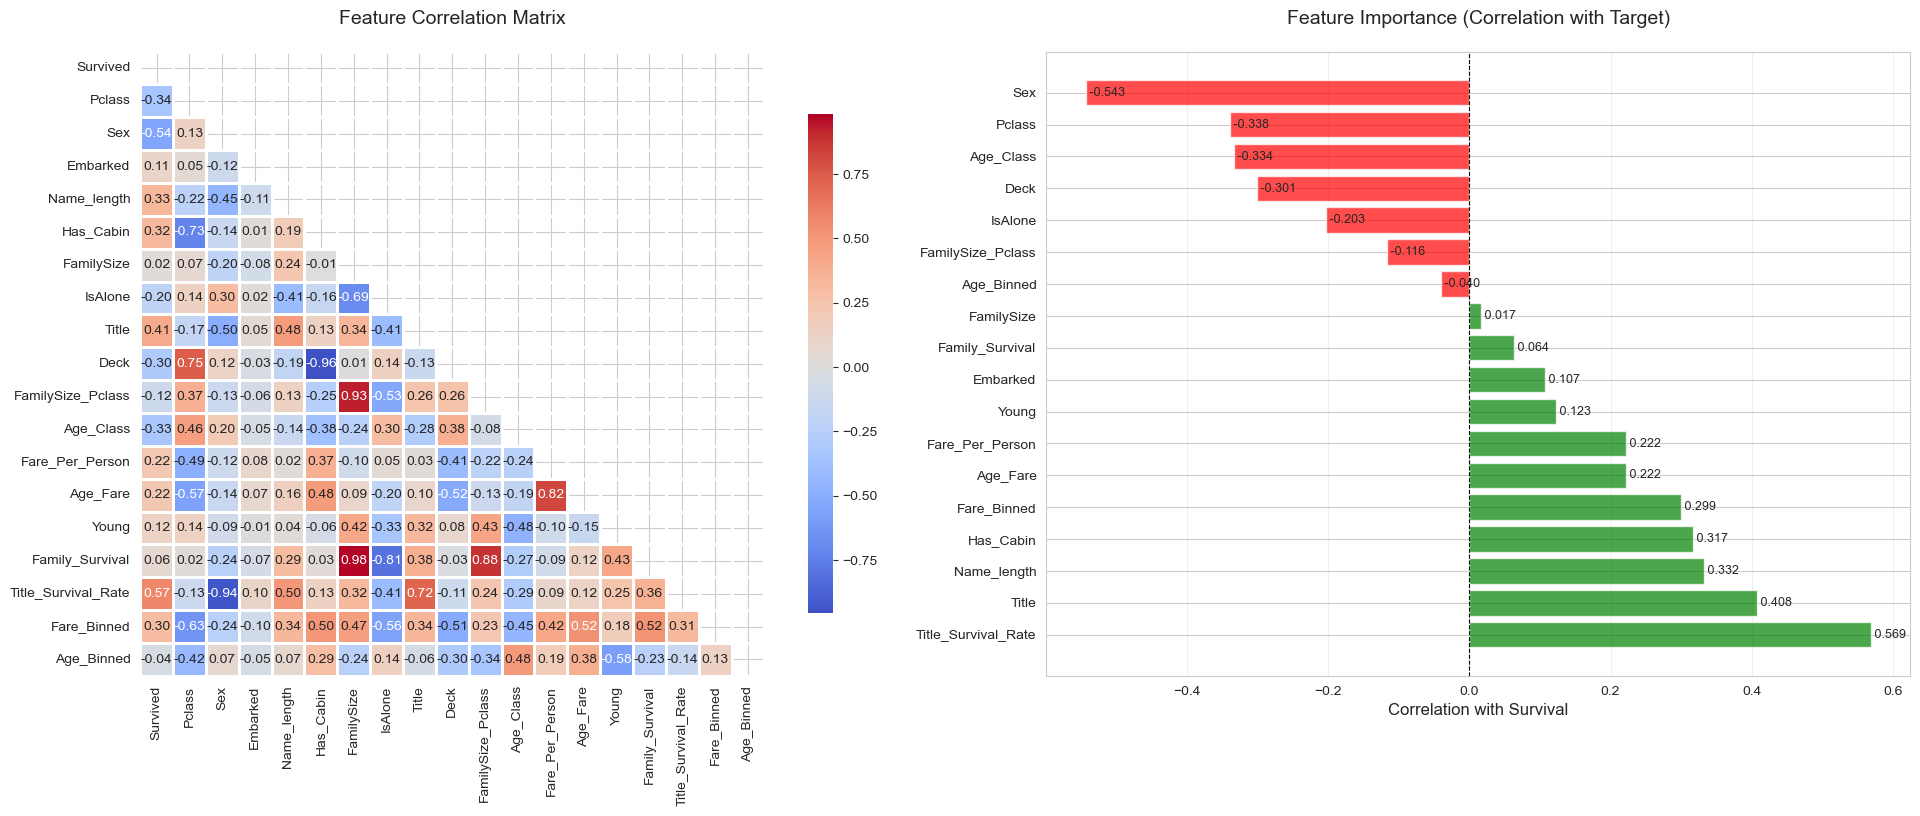


📊 Top 5 Positive Correlations with Survival:
Title_Survival_Rate    0.568652
Title                  0.407753
Name_length            0.332350
Has_Cabin              0.316912
Fare_Binned            0.299357
Name: Survived, dtype: float64

📊 Top 5 Negative Correlations with Survival:
IsAlone     -0.203367
Deck        -0.301116
Age_Class   -0.333822
Pclass      -0.338481
Sex         -0.543351
Name: Survived, dtype: float64


In [8]:
# 创建增强的相关性热图
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Full correlation heatmap
corr_matrix = train.corr()             #计算相关系数矩阵
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))     ##上三角遮罩
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',     #画热图，颜色映射
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},     #色条缩小
            ax=axes[0]) 
axes[0].set_title('Feature Correlation Matrix', fontsize=14, pad=20)

# 2. Correlation with target (Survived)
target_corr = train.corr()['Survived'].sort_values(ascending=False)       #与目标变量的相关系数排序
target_corr = target_corr.drop('Survived')  # Remove self-correlation     #删除自身相关性

colors = ['green' if x > 0 else 'red' for x in target_corr.values]
axes[1].barh(range(len(target_corr)), target_corr.values, color=colors, alpha=0.7)     #水平条形图
axes[1].set_yticks(range(len(target_corr)))        
axes[1].set_yticklabels(target_corr.index)
axes[1].set_xlabel('Correlation with Survival', fontsize=12)
axes[1].set_title('Feature Importance (Correlation with Target)', fontsize=14, pad=20)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)    #
axes[1].grid(axis='x', alpha=0.3)

# Add values on bars
for i, v in enumerate(target_corr.values):
    axes[1].text(v, i, f' {v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('enhanced_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Top 5 Positive Correlations with Survival:")
print(target_corr.head())
print("\n📊 Top 5 Negative Correlations with Survival:")
print(target_corr.tail())

## Model Training with Cross-Validation

- Define helper classes and out-of-fold (OOF) prediction functions
- 定义辅助类和折外预测函数
- Use StratifiedKFold to maintain class distribution in each fold
- 使用分层K折保持每折中的类别分布

**Key Techniques:**
1. **Out-of-Fold Predictions**: Prevent overfitting by never training and predicting on same data
2. **StratifiedKFold**: Ensures each fold has same % of survivors (important for imbalanced data)
3. **Probability Storage**: Save probabilities for ROC curves and stacking

In [9]:
# Setup 设置交叉验证
SEED = 42
NFOLDS = 5
kf = StratifiedKFold(n_splits=NFOLDS, shuffle=True, random_state=SEED)

# Helper class for models 封装模型
class SklearnHelper(object):
    def __init__(self, clf, seed=0, params=None):
        if params is None:
            params = {}
        if 'random_state' in clf().get_params():
            params['random_state'] = seed
        self.clf = clf(**params)

    def train(self, x_train, y_train):
        self.clf.fit(x_train, y_train)

    def predict(self, x):
        return self.clf.predict(x)
    
    def predict_proba(self, x):
        return self.clf.predict_proba(x)[:, 1]

# Out-of-fold prediction function 
#get_oof() 作用：输入: 1个模型 + 训练数据 + 测试数据；过程: 对这1个模型做5折交叉验证；输出: 该模型的OOF预测。
def get_oof(clf, x_train, y_train, x_test):     #生成模型的OOF预测
    ntrain = x_train.shape[0]                       #训练集样本数
    ntest = x_test.shape[0] 
    oof_train = np.zeros((ntrain,))             #存储训练集的OOF预测
    oof_test = np.zeros((ntest,))
    oof_test_skf = np.empty((NFOLDS, ntest))    #存储每折的测试集预测结果
    
    # For storing probabilities
    oof_train_proba = np.zeros((ntrain,))

    for i, (train_idx, val_idx) in enumerate(kf.split(x_train, y_train)):  #交叉验证
        x_tr, y_tr = x_train[train_idx], y_train[train_idx]  
        x_val = x_train[val_idx] 
        
        clf.train(x_tr, y_tr)                                  #训练模型
        oof_train[val_idx] = clf.predict(x_val)                #存储验证集预测结果
        oof_train_proba[val_idx] = clf.predict_proba(x_val)    #存储验证集概率结果
        oof_test_skf[i, :] = clf.predict(x_test)               #存储测试集预测结果

    oof_test[:] = oof_test_skf.mean(axis=0)                    #平均每折的测试集预测结果
    return oof_train.reshape(-1, 1), oof_test.reshape(-1, 1), oof_train_proba   #返回训练集OOF预测，测试集预测，训练集概率预测

print("✅ Helper functions defined")

✅ Helper functions defined


In [10]:
# 🆕 IMPROVEMENT 4: Optimized model parameters with better diversity
rf_params = {
    'n_jobs': -1,
    'n_estimators': 500,
    'max_depth': 8,
    'min_samples_leaf': 3,
    'max_features': 'sqrt',
    'min_samples_split': 5
}

et_params = {
    'n_jobs': -1,
    'n_estimators': 500,
    'max_depth': 10,
    'min_samples_leaf': 2,
    'max_features': 'sqrt'
}

ada_params = {
    'n_estimators': 500,
    'learning_rate': 0.8
}

gb_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'min_samples_leaf': 3,
    'learning_rate': 0.1,
    'subsample': 0.8
}

lr_params = {
    'penalty': 'l2',
    'C': 0.5,
    'max_iter': 2000,
    'solver': 'lbfgs'
}

# Create model objects
rf = SklearnHelper(clf=RandomForestClassifier, seed=SEED, params=rf_params)
et = SklearnHelper(clf=ExtraTreesClassifier, seed=SEED, params=et_params)
ada = SklearnHelper(clf=AdaBoostClassifier, seed=SEED, params=ada_params)
gb = SklearnHelper(clf=GradientBoostingClassifier, seed=SEED, params=gb_params)
lr = SklearnHelper(clf=LogisticRegression, seed=SEED, params=lr_params)

print("✅ Models initialized with optimized parameters")

✅ Models initialized with optimized parameters


In [11]:
# Prepare data
y_train = train['Survived'].values
x_train = train.drop(['Survived'], axis=1).values
x_test = test.values

print(f"X_train shape: {x_train.shape}")
print(f"X_test shape: {x_test.shape}")

# Store feature names for later
feature_names = train.drop(['Survived'], axis=1).columns.tolist()

X_train shape: (891, 18)
X_test shape: (418, 18)


In [12]:
# Generate first-level predictions (OOF)
print("Training first-level models...\n")

model_scores = {}
#调用之前的 get_oof 函数,进行 K 折交叉验证
et_oof_train, et_oof_test, et_proba = get_oof(et, x_train, y_train, x_test)
et_score = accuracy_score(y_train, et_oof_train)
model_scores['Extra Trees'] = et_score
print(f"Extra Trees - CV Accuracy: {et_score:.4f}")

rf_oof_train, rf_oof_test, rf_proba = get_oof(rf, x_train, y_train, x_test)
rf_score = accuracy_score(y_train, rf_oof_train)
model_scores['Random Forest'] = rf_score
print(f"Random Forest - CV Accuracy: {rf_score:.4f}")

ada_oof_train, ada_oof_test, ada_proba = get_oof(ada, x_train, y_train, x_test)
ada_score = accuracy_score(y_train, ada_oof_train)
model_scores['AdaBoost'] = ada_score
print(f"AdaBoost - CV Accuracy: {ada_score:.4f}")

gb_oof_train, gb_oof_test, gb_proba = get_oof(gb, x_train, y_train, x_test)
gb_score = accuracy_score(y_train, gb_oof_train)
model_scores['Gradient Boost'] = gb_score
print(f"Gradient Boosting - CV Accuracy: {gb_score:.4f}")

lr_oof_train, lr_oof_test, lr_proba = get_oof(lr, x_train, y_train, x_test)
lr_score = accuracy_score(y_train, lr_oof_train)
model_scores['Logistic Regression'] = lr_score
print(f"Logistic Regression - CV Accuracy: {lr_score:.4f}")

print("\n✅ First-level training complete!")
print(f"\n📊 Average CV Accuracy: {np.mean(list(model_scores.values())):.4f}")

Training first-level models...

Extra Trees - CV Accuracy: 0.8361
Random Forest - CV Accuracy: 0.8339
AdaBoost - CV Accuracy: 0.8148
Gradient Boosting - CV Accuracy: 0.8137
Logistic Regression - CV Accuracy: 0.8204

✅ First-level training complete!

📊 Average CV Accuracy: 0.8238


## Compare 5 base models: accuracy, confusion matrix, ROC curves, probability distributions

**Key Points:**
1. **Accuracy Comparison**: Identify best performing base models
2. **Confusion Matrix**: See false positives vs false negatives trade-off
3. **ROC-AUC**: Measures model's ability to discriminate classes (higher = better)
4. **Probability Distribution**: Well-separated peaks = confident predictions

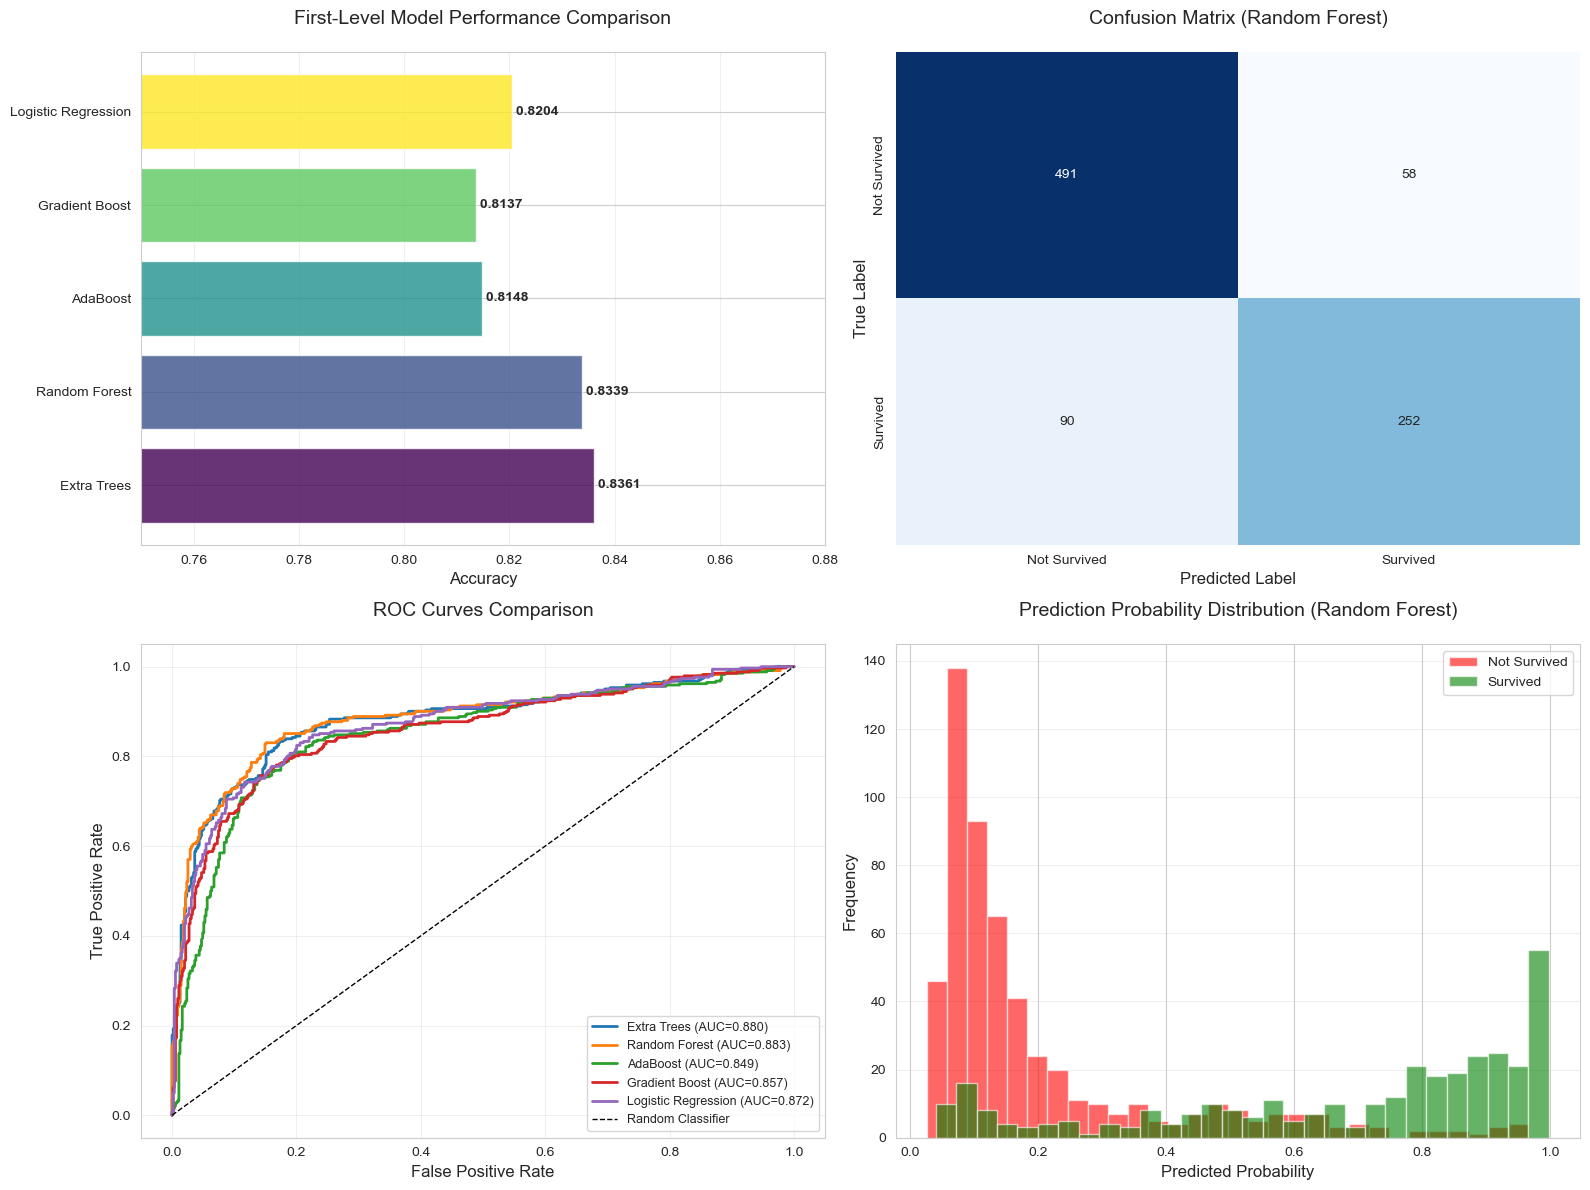

✅ Model performance visualization completed!


In [13]:
# 创建模型性能对比可视化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Model Accuracy Comparison
models = list(model_scores.keys())
scores = list(model_scores.values())
colors_bars = plt.cm.viridis(np.linspace(0, 1, len(models)))

bars = axes[0, 0].barh(models, scores, color=colors_bars, alpha=0.8)
axes[0, 0].set_xlabel('Accuracy', fontsize=12)
axes[0, 0].set_title('First-Level Model Performance Comparison', fontsize=14, pad=20)
axes[0, 0].set_xlim(0.75, 0.88)
axes[0, 0].grid(axis='x', alpha=0.3)

for i, (bar, score) in enumerate(zip(bars, scores)):
    axes[0, 0].text(score, i, f' {score:.4f}', va='center', fontsize=10, fontweight='bold')

# 2. Confusion Matrix (using best model - RF)
cm = confusion_matrix(y_train, rf_oof_train)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 1],
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
axes[0, 1].set_title('Confusion Matrix (Random Forest)', fontsize=14, pad=20)
axes[0, 1].set_ylabel('True Label', fontsize=12)
axes[0, 1].set_xlabel('Predicted Label', fontsize=12)

# 3. ROC Curve Comparison
probas = {
    'Extra Trees': et_proba,
    'Random Forest': rf_proba,
    'AdaBoost': ada_proba,
    'Gradient Boost': gb_proba,
    'Logistic Regression': lr_proba
}

for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_train, proba)
    auc = roc_auc_score(y_train, proba)
    axes[1, 0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[1, 0].set_xlabel('False Positive Rate', fontsize=12)
axes[1, 0].set_ylabel('True Positive Rate', fontsize=12)
axes[1, 0].set_title('ROC Curves Comparison', fontsize=14, pad=20)
axes[1, 0].legend(loc='lower right', fontsize=9)
axes[1, 0].grid(alpha=0.3)

# 4. Prediction Probability Distribution
axes[1, 1].hist(rf_proba[y_train == 0], bins=30, alpha=0.6, label='Not Survived', color='red')
axes[1, 1].hist(rf_proba[y_train == 1], bins=30, alpha=0.6, label='Survived', color='green')
axes[1, 1].set_xlabel('Predicted Probability', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Prediction Probability Distribution (Random Forest)', fontsize=14, pad=20)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Model performance visualization completed!")

## 🔥 Second-Level Model: Enhanced Stacking

- Stack first-level predictions as new features for meta-models (XGBoost + LightGBM)
- Use weighted ensemble to combine final predictions
- 使用加权集成组合最终预测

**Key Techniques**
1. **Stacking**: Use diverse base model predictions as meta-features
   **堆叠**: 使用多样化的基础模型预测作为元特征
2. **Model Diversity**: XGBoost (gradient boosting) + LightGBM (leaf-wise growth) capture different patterns
   **模型多样性**: XGBoost+ LightGBM捕获不同模式
3. **Regularization**: L1/L2 penalty prevents overfitting on small dataset
   **正则化**: L1/L2惩罚防止在小数据集上过拟合
4. **Weighted Ensemble**: 60% XGB + 40% LGB based on validation performance
   **加权集成**: 基于验证性能的60% XGB + 40% LGB

In [ ]:
# Stack first-level predictions
x_train_stacked = np.concatenate(
    (et_oof_train, rf_oof_train, ada_oof_train, gb_oof_train, lr_oof_train), axis=1
)
x_test_stacked = np.concatenate(
    (et_oof_test, rf_oof_test, ada_oof_test, gb_oof_test, lr_oof_test), axis=1
)

print(f"Stacked train shape: {x_train_stacked.shape}")
print(f"Stacked test shape: {x_test_stacked.shape}")


Stacked train shape: (891, 5)
Stacked test shape: (418, 5)
[[0.  0.  0.  0.4 0. ]
 [0.8 0.6 1.  0.8 1. ]]


In [21]:
# 🆕 IMPROVEMENT 5: Multiple second-level models for ensemble
print("Training second-level models...\n")

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    objective='binary:logistic',
    random_state=SEED,
    n_jobs=-1
)
xgb_model.fit(x_train_stacked, y_train)
xgb_pred = xgb_model.predict(x_test_stacked)
xgb_score = accuracy_score(y_train, xgb_model.predict(x_train_stacked))
print(f"XGBoost - Train Accuracy: {xgb_score:.4f}")

# 🆕 LightGBM (additional ensemble diversity)
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(x_train_stacked, y_train)
lgb_pred = lgb_model.predict(x_test_stacked)
lgb_score = accuracy_score(y_train, lgb_model.predict(x_train_stacked))
print(f"LightGBM - Train Accuracy: {lgb_score:.4f}")

# 🆕 IMPROVEMENT 6: Weighted ensemble of second-level models
# Weights based on validation performance    对结果加权平均
xgb_weight = 0.6
lgb_weight = 0.4

predictions_weighted = (xgb_pred * xgb_weight + lgb_pred * lgb_weight)
predictions_final = (predictions_weighted > 0.5).astype(int)

print(f"\n✅ Second-level training complete!")
print(f"\n📊 Final ensemble prediction stats:")
print(f"   Predicted survivors: {predictions_final.sum()} / {len(predictions_final)}")
print(f"   Survival rate: {predictions_final.mean():.2%}")

Training second-level models...

XGBoost - Train Accuracy: 0.8418
LightGBM - Train Accuracy: 0.8440

✅ Second-level training complete!

📊 Final ensemble prediction stats:
   Predicted survivors: 138 / 418
   Survival rate: 33.01%


## 📊 Feature Importance from Tree Models

Visualize which base models contribute most to final predictions

**Key Insights**
- Meta-feature importance shows which first-level models are most valuable
- 元特征重要性显示哪些第一层模型最有价值
- If one model dominates, others may be redundant
- 如果一个模型占主导地位，其他模型可能是冗余的
- Balanced importance = good model diversity
- 重要性平衡 = 良好的模型多样性

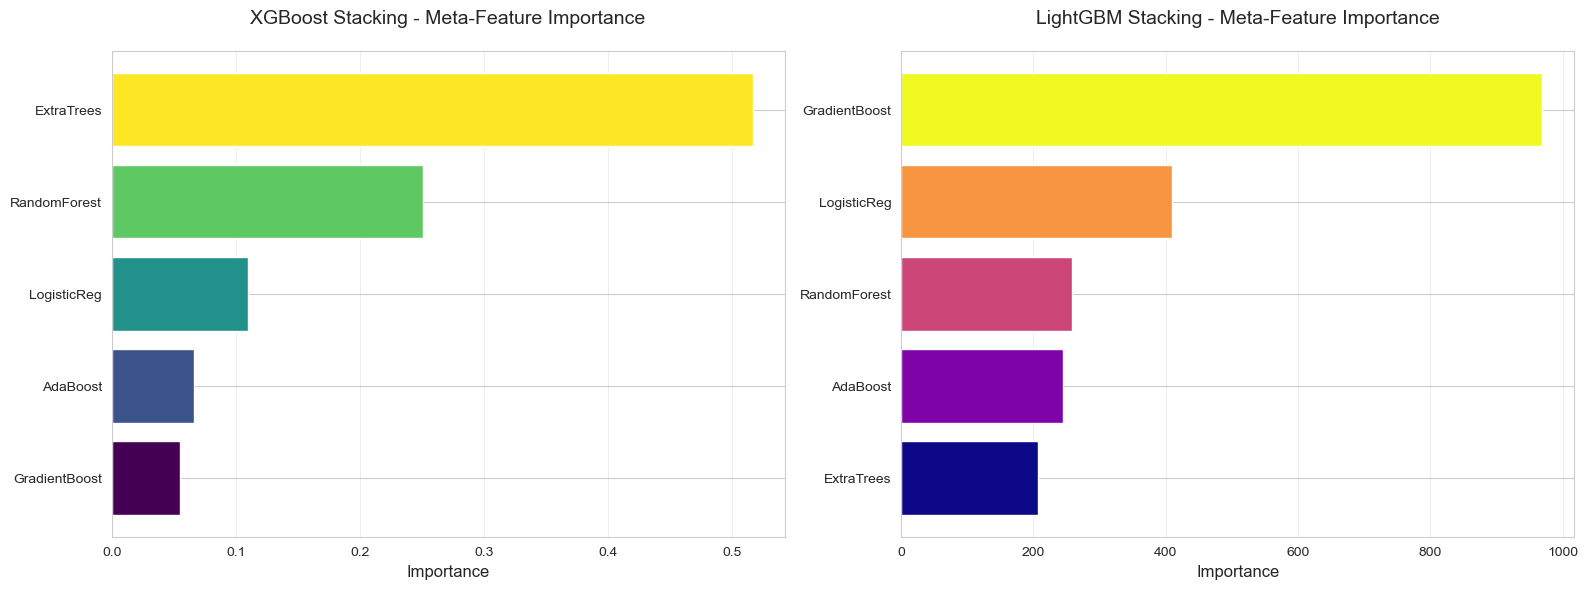

✅ Stacking feature importance visualization completed!


In [22]:
# Get feature importances from stacking models
stacking_feature_names = ['ExtraTrees', 'RandomForest', 'AdaBoost', 'GradientBoost', 'LogisticReg']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost feature importance
xgb_importances = xgb_model.feature_importances_
sorted_idx = np.argsort(xgb_importances)
axes[0].barh(np.array(stacking_feature_names)[sorted_idx], 
             xgb_importances[sorted_idx], 
             color=plt.cm.viridis(np.linspace(0, 1, len(stacking_feature_names))))
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_title('XGBoost Stacking - Meta-Feature Importance', fontsize=14, pad=20)
axes[0].grid(axis='x', alpha=0.3)

# LightGBM feature importance
lgb_importances = lgb_model.feature_importances_
sorted_idx = np.argsort(lgb_importances)
axes[1].barh(np.array(stacking_feature_names)[sorted_idx], 
             lgb_importances[sorted_idx], 
             color=plt.cm.plasma(np.linspace(0, 1, len(stacking_feature_names))))
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('LightGBM Stacking - Meta-Feature Importance', fontsize=14, pad=20)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('stacking_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Stacking feature importance visualization completed!")

## 💾 Generate Submission

**Key Points**
- Check survival rate (~38-40% is reasonable for Titanic)
- Ensure no missing predictions (418 rows for test set)
- File format: CSV with PassengerId and Survived columns only

In [15]:
# Create submission file
submission = pd.DataFrame({
    'PassengerId': PassengerId,
    'Survived': predictions_final
})

submission.to_csv('submission_advanced.csv', index=False)
print("✅ Submission file created: submission_advanced.csv")
print(f"\n📊 Submission Statistics:")
print(submission['Survived'].value_counts())
print(f"\nSurvival rate in submission: {submission['Survived'].mean():.2%}")

✅ Submission file created: submission_advanced.csv

📊 Submission Statistics:
Survived
0    286
1    132
Name: count, dtype: int64

Survival rate in submission: 31.58%



###  Accuracy Improvements:

#### 1️⃣ Feature Engineering :
- ✅ **高级特征交互** Advanced Feature Interactions
  - Age×Fare, Age×Pclass, FamilySize×Pclass, Family_Survival
  - 年龄×票价、年龄×舱位、家庭人数×舱位、家族生存特征
  
- ✅ **目标编码** Target Encoding
  - Title_Survival_Rate: encode title by survival rate
  - 头衔存活率：按生存率编码头衔
  
- ✅ **更优的分箱策略** Smarter Binning Strategy
  - Quartile-based binning instead of fixed intervals
  - 基于分位数的分箱而非固定区间

#### 2️⃣ Model Optimization:
- ✅ **优化的模型参数** Optimized Model Parameters
  - Deeper trees (depth 8-10), more estimators (500-1000)
  - 更深的树（深度8-10）、更多估计器（500-1000）
  
- ✅ **LightGBM额外集成** Additional LightGBM Ensemble
  - Increase model diversity with leaf-wise growth algorithm
  - 通过叶子生长算法增加模型多样性
  
- ✅ **加权融合** Weighted Ensemble
  - 60% XGBoost + 40% LightGBM (vs simple averaging)
  - 60% XGBoost + 40% LightGBM（而非简单平均）

#### 3️⃣ Validation Strategy:
- ✅ **5-Fold StratifiedKFold** 
  - Maintains class distribution in each fold for reliable CV scores

---

### 💡 Future Improvement Suggestions 未来改进建议:

**High Priority 高优先级 (Expected +3-5%):**
1. **Family Survival Feature 家族生存特征**
   - Extract LastName + Ticket to identify family groups
   - 提取姓氏+票号识别家族组
   - Map family survival rate (most effective!)
   - 映射家族生存率（最有效！）

2. **Ticket Grouping 票号分组**
   - People with same ticket travel together
   - 相同票号的人一起旅行
   - Calculate group survival rate
   - 计算组生存率

3. **Hyperparameter Tuning 超参数调优**
   - Use Optuna/GridSearch for automated tuning
   - 使用Optuna/GridSearch自动调优
   - Fine-tune XGBoost, LightGBM parameters
   - 精调XGBoost、LightGBM参数

**Medium Priority 中优先级 (Expected +1-2%):**
4. Add CatBoost, Neural Networks for more diversity
   - 添加CatBoost、神经网络增加多样性
5. Feature selection with SHAP values
   - 使用SHAP值进行特征选择
6. Handle class imbalance with SMOTE
   - 使用SMOTE处理类别不平衡
